Saving Iris (1).csv to Iris (1) (2).csv
INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

DESKRIPSI:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000     

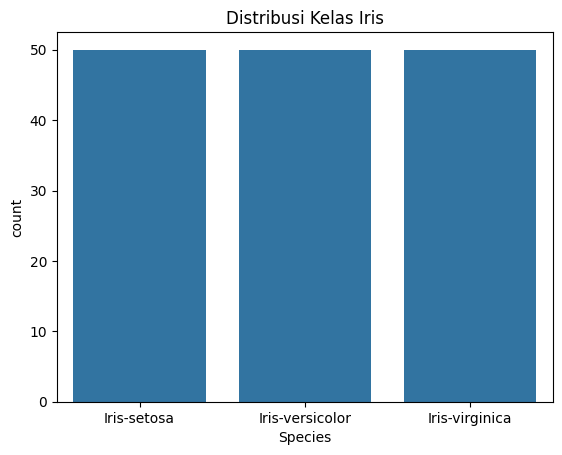

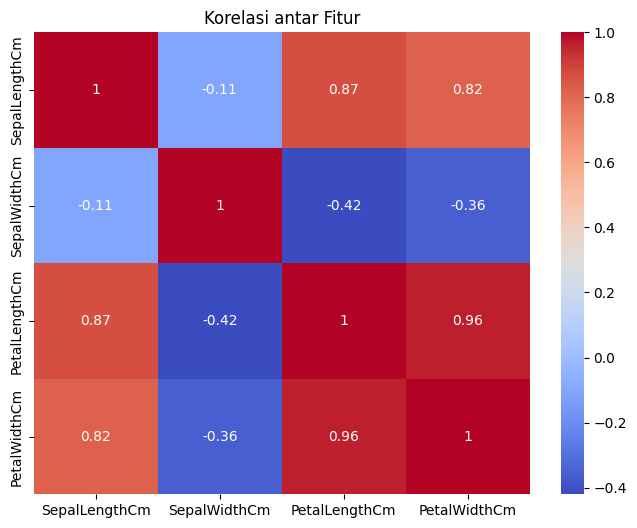

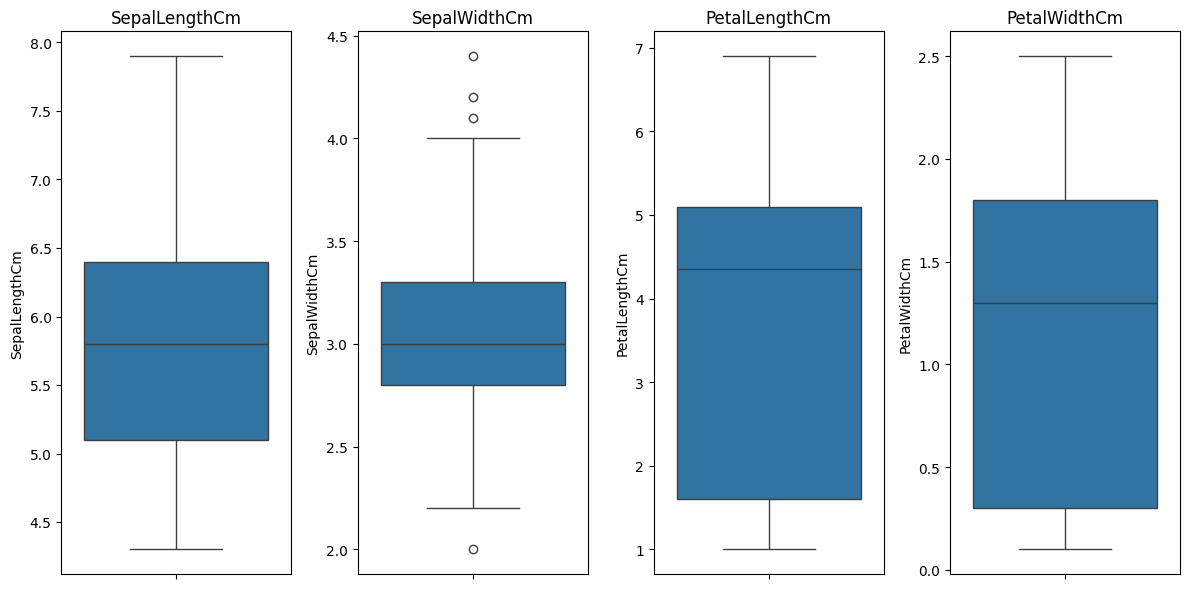

interactive(children=(Dropdown(description='Species:', options=('All', 'Iris-setosa', 'Iris-versicolor', 'Iris…

<function __main__.update_plot(species)>

In [ ]:
# Nama Dan Nim

#Christian Ernesto Lie(103052300072)


# Import library upload file
from google.colab import files

# Upload file CSV
uploaded = files.upload()

# Setelah upload, kita ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# 1. Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# 2. Load data dari file yang diupload
df = pd.read_csv(filename)
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# 3. Ringkasan awal
print("INFO:")
print(df.info())
print("\nDESKRIPSI:")
print(df.describe())
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLIKAT:", df.duplicated().sum())

# 4. Visualisasi distribusi kelas
sns.countplot(data=df, x='Species')
plt.title('Distribusi Kelas Iris')
plt.show()

# 5. Korelasi antar fitur
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur')
plt.show()

# 6. Boxplot untuk outlier
plt.figure(figsize=(12, 6))
for i, col in enumerate(df.select_dtypes(include=np.number).columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# 7. Plot interaktif - Scatter
fig = px.scatter(df,
                 x="PetalLengthCm",
                 y="PetalWidthCm",
                 color="Species",
                 size="SepalLengthCm",
                 hover_data=["SepalWidthCm"],
                 title="Petal Length vs Petal Width per Species")
fig.show()

# 8. Plot interaktif - Histogram
fig = px.histogram(df,
                   x="SepalLengthCm",
                   color="Species",
                   nbins=20,
                   marginal="box",
                   title="Distribusi Sepal Length per Species")
fig.show()

# 9. Widget interaktif - Filter berdasarkan spesies
species_options = df['Species'].unique().tolist()
dropdown = widgets.Dropdown(
    options=['All'] + species_options,
    description='Species:',
    value='All'
)

def update_plot(species):
    if species == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['Species'] == species]

    fig = px.scatter(filtered_df,
                     x="SepalLengthCm",
                     y="SepalWidthCm",
                     color="Species",
                     title=f"Scatter Sepal Length vs Width ({species})")
    fig.show()

widgets.interact(update_plot, species=dropdown)
